# Notebook 2: Learning a Power-Flow Surrogate
### Applied AI for Power and Energy Systems Workshop
**CSU Energy Institute AI Bootcamp — Week 3**

## What you will build in this notebook

A nueral network that approximates AC power flow equation -- and a physic-informed version that stays physically consistent even outside its training range.

**Three models, head-to-head:**
| Model | What it does |
|---|---|
| pandapower | Solves the real physics equations (ground truth) |
| Pure MLP | Learns the input→output mapping from data only |
| PINN | Same MLP, but trained with a physics penalty term |

**Learning objectives:**
1. Understand what power flow is and why a surrogate is useful
2. Generate supervised-learning data from a physics simulator
3. Train a neural-network surrogate and evaluate it
4. See what happens when the surrogate is tested outside its training range
5. Understand how physics-informed learning improves out-of-distribution behaviour

## Section 1 — Conceptual Setup

### 1.1 What is power flow?

A power network is a set of **buses** (nodes) connected by **lines** (edges). At every bus, power is either:
- **Consumed** — by loads (homes, factories, etc.)
- **Injected** — by generators or solar panels

Given the power consumed and injected at every bus, the physics equations determine the **voltage** at every bus. Solving those equations is called **power flow analysis**.

```
Bus 0 (Slack/Grid)          voltage fixed at 1.0 pu
    │
  Bus 1 (Load)              consumes P₁, Q₁  →  what is |V₁|, δ₁ ?
    │
  Bus 2 (Load)              consumes P₂, Q₂  →  what is |V₂|, δ₂ ?
   / \
Bus 3   Bus 4               Bus 3: solar injects P_solar, Q_solar
(Solar) (Load)              Bus 4: consumes P₄, Q₄
```

### 1.2 Why do we need a surrogate?

Solving AC power flow requires an iterative numerical solver (Newton-Raphson). In real grid operations, you may need to solve it **thousands of times per second** — for optimization, planning, contingency analysis, and control.

A neural network that **approximates** the solution instantly is called a **surrogate model**.

### 1.3 What exactly are we learning?

```
INPUTS  (what we know)              OUTPUTS  (what we predict)
──────────────────────              ────────────────────────────
P_load, Q_load at buses 1,2,4  →   |V| at buses 1,2,3,4  (voltage magnitudes)
P_solar, Q_solar at bus 3      →   δ  at buses 1,2,3,4  (voltage angles)

INPUT DIM  = 8
OUTPUT DIM = 8

Then: line flows are DERIVED mathematically from predicted voltages
       (no ML needed — pure physics post-processing)
```

### 1.4 What is a PINN?

A **Physics-Informed Neural Network** adds a physics penalty to the standard data loss:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda \cdot \mathcal{L}_{\text{physics}}$$

The physics residual penalises predictions that violate the **AC power balance equations**:

$$P_i = |V_i| \sum_k |V_k| \left( G_{ik}\cos(\delta_i - \delta_k) + B_{ik}\sin(\delta_i - \delta_k) \right)$$

If the predicted voltages do not satisfy this equation, the loss increases — pushing the model toward physically valid solutions.

**Key insight:** Inside the training range, MLP ≈ PINN. Outside it (OOD data), PINN degrades more slowly because physics keeps it anchored.

---
## Section 2 -- Environment Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")
if IN_COLAB:
    %pip install -q pandapower gdown scikit-learn
    


Running in Colab: False


In [2]:
import sys
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import pandapower as pp

print("NumPy    :", np.__version__)
print("PyTorch  :", torch.__version__)
print("Pandas   :", pd.__version__)
print("Pandapower:", pp.__version__)

NumPy    : 2.3.5
PyTorch  : 2.12.0+cpu
Pandas   : 2.3.3
Pandapower: 3.4.0


In [8]:
# ─────────────────────────────────────────────────────────────
# Project paths
# Run this cell from the notebooks/ folder or project root.
# ─────────────────────────────────────────────────────────────
import sys
from pathlib import Path

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/ai-energy-workshop")
else:
    # Try relative path first (notebook is inside notebooks/)
    PROJECT_DIR = Path("../").resolve()

    # Fallback: if relative path didn't resolve correctly, use absolute
    if not (PROJECT_DIR / "src" / "workshop_utils").exists():
        PROJECT_DIR = Path(
            r"C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop"
        )

DATA_DIR  = PROJECT_DIR / "data"   / "workshop"
MODEL_DIR = PROJECT_DIR / "models"
SRC_DIR   = PROJECT_DIR / "src"

# Add src/ to Python path — done here so all imports work in every cell
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Verify
print("Project dir      :", PROJECT_DIR)
print("Data dir         :", DATA_DIR)
print("Models dir       :", MODEL_DIR)
print("SRC_DIR          :", SRC_DIR)
print("SRC_DIR exists   :", SRC_DIR.exists())
print("workshop_utils   :", (SRC_DIR / "workshop_utils").exists())
print("Data exists      :", DATA_DIR.exists())
print("sys.path[0]      :", sys.path[0])

# Immediately verify the import works
try:
    from workshop_utils.model_io import download_model_if_missing, load_checkpoint
    print("\nworkshop_utils import : OK")
except ModuleNotFoundError as e:
    print(f"\nworkshop_utils import : FAILED — {e}")
    print("Check that src/workshop_utils/__init__.py exists")

Project dir      : C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop
Data dir         : C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\data\workshop
Models dir       : C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models
SRC_DIR          : C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\src
SRC_DIR exists   : True
workshop_utils   : True
Data exists      : True
sys.path[0]      : C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\src

workshop_utils import : OK


In [7]:
print("SRC_DIR:", SRC_DIR)
print("SRC_DIR exists:", SRC_DIR.exists())
import sys
print("sys.path[0]:", sys.path[0])

SRC_DIR: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\src
SRC_DIR exists: True
sys.path[0]: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\src


In [9]:
# ─────────────────────────────────────────────────────────────
# Reproducibility and device
# ─────────────────────────────────────────────────────────────
SEED = 469
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Random seed : {SEED}")
print(f"Device      : {device}")

sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"]      = 11

Random seed : 469
Device      : cpu


---
## Section 3 — Download Models from Google Drive

In [10]:
# ─────────────────────────────────────────────────────────────
# Import download helper
# ─────────────────────────────────────────────────────────────
from workshop_utils.model_io import download_model_if_missing, load_checkpoint
print("model_io loaded.")

model_io loaded.


In [11]:
# ─────────────────────────────────────────────────────────────
# Google Drive file IDs
# ─────────────────────────────────────────────────────────────
GDRIVE_IDS = {
    # Instructor models (fully trained)
    "power_flow_pretrained.pt"            : "1qklDhFo-NQoK1OjoaOy9aTkx6Oce8rHz",
    "power_flow_pinn_pretrained.pt"       : "1ElgcpeOqt9IYTC3tiCOjRY38JT26cVVt",
    "power_flow_scalers.pkl"              : "15Y0EhUmhFvghbT0oTjUU_TRZfb72z3T3",
    "power_flow_training_curves.json"     : "1hy9A_GoJAB8tEqh1vTztLt83tB_AwTbs",
    "power_flow_pinn_training_curves.json": "1rodp8JU7_cEizm4JurNFAfH0_4ka3rta",
    # Starting-point models (for participant fine-tuning)
    "power_flow_starting_point.pt"        : "1k9c58mB9cBRmV3WQkDGQXG9RjM47Fx_Q",
    "power_flow_pinn_starting_point.pt"   : "1OfimpPoGo1UtGyv7O4VUnczRGSm34dPg",
}
print("Drive IDs registered:", len(GDRIVE_IDS), "files")

Drive IDs registered: 7 files


In [12]:
# ─────────────────────────────────────────────────────────────
# Download all model files
# Downloads are skipped if the file already exists locally.
# ─────────────────────────────────────────────────────────────
INSTRUCTOR_DIR   = MODEL_DIR / "instructor"
STARTING_DIR     = MODEL_DIR / "starting_points"
INSTRUCTOR_DIR.mkdir(parents=True, exist_ok=True)
STARTING_DIR.mkdir(parents=True,   exist_ok=True)

# Instructor files
for fname in [
    "power_flow_pretrained.pt",
    "power_flow_pinn_pretrained.pt",
    "power_flow_scalers.pkl",
    "power_flow_training_curves.json",
    "power_flow_pinn_training_curves.json",
]:
    download_model_if_missing(
        path      = INSTRUCTOR_DIR / fname,
        gdrive_id = GDRIVE_IDS[fname],
    )

# Starting-point files
for fname in [
    "power_flow_starting_point.pt",
    "power_flow_pinn_starting_point.pt",
]:
    download_model_if_missing(
        path      = STARTING_DIR / fname,
        gdrive_id = GDRIVE_IDS[fname],
    )

print("\nAll model files ready.")

Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_pretrained.pt  (0.11 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_pinn_pretrained.pt  (0.11 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_scalers.pkl  (0.00 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_training_curves.json  (0.01 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_pinn_training_curves.json  (0.03 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\starting_points\power_flow_starting_point.pt  (0.11 MB)
Model already present: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\starting

---
## Section 4 — Load Dataset and Explore

In [13]:
# ─────────────────────────────────────────────────────────────
# Load CSV
# ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / "power_flow_samples.csv")

with open(DATA_DIR / "power_flow_meta.json") as f:
    meta = json.load(f)

IN_COLS  = meta["input_features"]   # 8 columns
OUT_COLS = meta["output_features"]  # 8 columns

print(f"Dataset shape : {df.shape}")
print(f"Splits        : {df['split'].value_counts().to_dict()}")
print(f"\nInput features  ({len(IN_COLS)}): {IN_COLS}")
print(f"Output features ({len(OUT_COLS)}): {OUT_COLS}")

Dataset shape : (6000, 17)
Splits        : {'train': 5000, 'ood_test': 1000}

Input features  (8): ['P_load1_MW', 'Q_load1_MVAr', 'P_load2_MW', 'Q_load2_MVAr', 'P_load4_MW', 'Q_load4_MVAr', 'P_solar_MW', 'Q_solar_MVAr']
Output features (8): ['Vm_bus1_pu', 'Vm_bus2_pu', 'Vm_bus3_pu', 'Vm_bus4_pu', 'Va_bus1_deg', 'Va_bus2_deg', 'Va_bus3_deg', 'Va_bus4_deg']


In [14]:
df.head(5)

,P_load1_MW,Q_load1_MVAr,P_load2_MW,Q_load2_MVAr,P_load4_MW,Q_load4_MVAr,P_solar_MW,Q_solar_MVAr,Vm_bus1_pu,Vm_bus2_pu,Vm_bus3_pu,Vm_bus4_pu,Va_bus1_deg,Va_bus2_deg,Va_bus3_deg,Va_bus4_deg,split
0,1.503046,0.501015,2.378446,0.832456,0.889301,0.266790,0.571305,0.099240,0.992888,0.987389,0.988150,0.985137,0.079183,0.144116,0.141425,0.162921,train
1,1.443416,0.481139,2.336754,0.817864,0.999771,0.299931,0.525676,-0.213945,0.992727,0.986916,0.987566,0.984382,0.107437,0.208120,0.228621,0.229630,train
2,1.472399,0.490800,1.675108,0.586288,1.156375,0.346913,1.006940,-0.096993,0.994360,0.990561,0.991850,0.987639,0.091653,0.172241,0.188474,0.197353,train
3,1.471548,0.490516,2.001541,0.700539,1.056839,0.317052,0.687395,0.173590,0.993508,0.988688,0.989611,0.986014,0.067973,0.119960,0.112813,0.142766,train
4,1.482176,0.494059,2.219537,0.776838,1.118476,0.335543,0.663631,0.218039,0.992980,0.987549,0.988450,0.984715,0.069259,0.122605,0.111861,0.146967,train


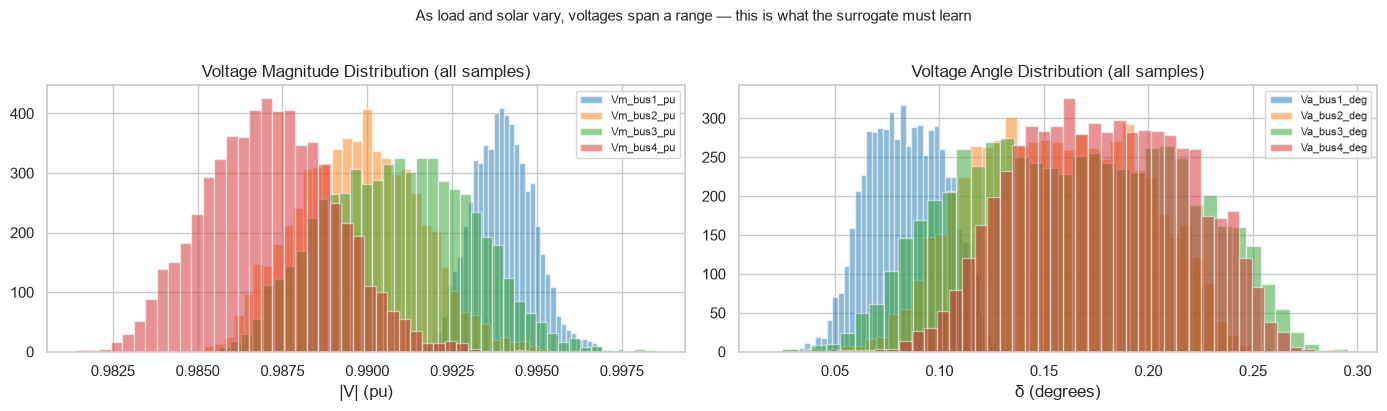


Observation: Voltage drops from Bus 1 → Bus 4 as we move further from the slack bus.


In [15]:
# ─────────────────────────────────────────────────────────────
# Explore: voltage distribution across the network
# ─────────────────────────────────────────────────────────────
vm_cols = [c for c in OUT_COLS if "Vm" in c]
va_cols = [c for c in OUT_COLS if "Va" in c]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for col in vm_cols:
    axes[0].hist(df[col], bins=40, alpha=0.5, label=col)
axes[0].set_title("Voltage Magnitude Distribution (all samples)")
axes[0].set_xlabel("|V| (pu)")
axes[0].legend(fontsize=8)

for col in va_cols:
    axes[1].hist(df[col], bins=40, alpha=0.5, label=col)
axes[1].set_title("Voltage Angle Distribution (all samples)")
axes[1].set_xlabel("δ (degrees)")
axes[1].legend(fontsize=8)

plt.suptitle(
    "As load and solar vary, voltages span a range — this is what the surrogate must learn",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()
print("\nObservation: Voltage drops from Bus 1 → Bus 4 as we move further from the slack bus.")

In [16]:
# ─────────────────────────────────────────────────────────────
# Quick statistics
# ─────────────────────────────────────────────────────────────
print("Training split statistics:")
df[df["split"]=="train"][IN_COLS + OUT_COLS].describe().round(4)

Training split statistics:


,P_load1_MW,Q_load1_MVAr,P_load2_MW,Q_load2_MVAr,P_load4_MW,Q_load4_MVAr,P_solar_MW,Q_solar_MVAr,Vm_bus1_pu,Vm_bus2_pu,Vm_bus3_pu,Vm_bus4_pu,Va_bus1_deg,Va_bus2_deg,Va_bus3_deg,Va_bus4_deg
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,1.5028,0.5009,1.9936,0.6978,1.0010,0.3003,0.8991,0.0029,0.9939,0.9896,0.9907,0.9870,0.0858,0.1587,0.1664,0.1801
std,0.1713,0.0571,0.2322,0.0813,0.1154,0.0346,0.3479,0.1732,0.0008,0.0016,0.0020,0.0017,0.0176,0.0384,0.0513,0.0388
min,1.2001,0.4000,1.6001,0.5600,0.8000,0.2400,0.3005,-0.2999,0.9917,0.9853,0.9857,0.9824,0.0412,0.0635,0.0454,0.0813
25%,1.3573,0.4524,1.7849,0.6247,0.8985,0.2696,0.5921,-0.1482,0.9933,0.9883,0.9892,0.9858,0.0718,0.1278,0.1246,0.1493
50%,1.5060,0.5020,1.9919,0.6972,1.0043,0.3013,0.9013,0.0071,0.9939,0.9896,0.9907,0.9870,0.0856,0.1581,0.1656,0.1798
75%,1.6495,0.5498,2.1954,0.7684,1.1017,0.3305,1.2029,0.1522,0.9944,0.9908,0.9922,0.9883,0.0996,0.1896,0.2086,0.2109
max,1.7999,0.6000,2.3999,0.8400,1.1999,0.3600,1.4998,0.2999,0.9962,0.9941,0.9960,0.9920,0.1324,0.2600,0.2955,0.2857


---
## Section 5 — Model Architecture

Both the pure MLP and the PINN use **identical architecture**. The only difference is the loss function used during training.

```
Input (8)  →  Linear(128) → BatchNorm → ReLU
           →  Linear(128) → BatchNorm → ReLU
           →  Linear(64)  → BatchNorm → ReLU
           →  Linear(8)   →  Output
```

**BatchNorm** is important here because input features (MW, MVAr) and output features (pu, degrees) are on very different scales.

In [17]:
# ─────────────────────────────────────────────────────────────
# Define the MLP architecture
# Both models (MLP and PINN) use this exact class
# ─────────────────────────────────────────────────────────────
class PowerFlowMLP(nn.Module):
    """
    Feedforward MLP surrogate for AC power flow.

    Architecture: Input → [Linear → BatchNorm → ReLU] × 3 → Linear → Output
    """
    def __init__(self, input_dim=8, output_dim=8, hidden_dims=[128, 128, 64]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Print architecture
example_model = PowerFlowMLP()
print(example_model)
n_params = sum(p.numel() for p in example_model.parameters())
print(f"\nTotal parameters: {n_params:,}")

PowerFlowMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=8, bias=True)
  )
)

Total parameters: 27,080


---
## Section 6 — Working Example: Load and Run the Pretrained Models

In [18]:
# ─────────────────────────────────────────────────────────────
# Load scalers
# The StandardScaler fitted on training data.
# Required to convert model outputs back to physical units.
# ─────────────────────────────────────────────────────────────
with open(INSTRUCTOR_DIR / "power_flow_scalers.pkl", "rb") as f:
    scalers  = pickle.load(f)
scaler_X = scalers["scaler_X"]
scaler_y = scalers["scaler_y"]
print("Scalers loaded.")
print(f"  scaler_X mean (first 3): {scaler_X.mean_[:3].round(4)}")
print(f"  scaler_y mean (first 3): {scaler_y.mean_[:3].round(4)}")

Scalers loaded.
  scaler_X mean (first 3): [1.5034 0.5011 1.9943]
  scaler_y mean (first 3): [0.9939 0.9895 0.9907]


In [19]:
# ─────────────────────────────────────────────────────────────
# Load pretrained MLP (instructor model)
# ─────────────────────────────────────────────────────────────
model_mlp = PowerFlowMLP().to(device)
model_mlp, meta_mlp = load_checkpoint(
    model_mlp,
    INSTRUCTOR_DIR / "power_flow_pretrained.pt",
    device,
)
print(f"\nMLP trained for : {meta_mlp.get('epochs_trained','?')} epochs")
print(f"Final val loss  : {meta_mlp.get('final_val_loss','?'):.6f}")
print(f"Training range  : load {meta_mlp.get('load_range','?')}")

Loaded model from: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_pretrained.pt
  Trained for 200 epochs  |  val loss: 0.00036476403086756665

MLP trained for : 200 epochs
Final val loss  : 0.000365
Training range  : load [0.8, 1.2]


In [20]:
# ─────────────────────────────────────────────────────────────
# Load pretrained PINN (instructor model)
# ─────────────────────────────────────────────────────────────
model_pinn = PowerFlowMLP().to(device)
model_pinn, meta_pinn = load_checkpoint(
    model_pinn,
    INSTRUCTOR_DIR / "power_flow_pinn_pretrained.pt",
    device,
)
print(f"\nPINN trained for  : {meta_pinn.get('epochs_trained','?')} epochs")
print(f"Final val loss    : {meta_pinn.get('final_val_loss','?'):.6f}")
print(f"Physics weight λ  : {meta_pinn.get('lambda_physics','?')}")

Loaded model from: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\instructor\power_flow_pinn_pretrained.pt
  Trained for 200 epochs  |  val loss: 0.00036020314049286145

PINN trained for  : 200 epochs
Final val loss    : 0.000360
Physics weight λ  : 0.1


In [21]:
# ─────────────────────────────────────────────────────────────
# Prediction helper
# ─────────────────────────────────────────────────────────────
def predict(model, X_raw):
    """Scale inputs → run model → inverse-scale outputs → physical units."""
    X_sc = torch.tensor(
        scaler_X.transform(X_raw).astype("float32")
    ).to(device)
    with torch.no_grad():
        y_sc = model(X_sc).cpu().numpy()
    return scaler_y.inverse_transform(y_sc)

print("predict() helper defined.")

predict() helper defined.


In [22]:
# ─────────────────────────────────────────────────────────────
# Run predictions on in-distribution test set
# ─────────────────────────────────────────────────────────────
df_test = (
    df[df["split"] == "train"]
    .sample(500, random_state=SEED)
    .reset_index(drop=True)
)
df_ood = df[df["split"] == "ood_test"].reset_index(drop=True)

X_test  = df_test[IN_COLS].values.astype("float32")
y_test  = df_test[OUT_COLS].values.astype("float32")
X_ood   = df_ood[IN_COLS].values.astype("float32")
y_ood   = df_ood[OUT_COLS].values.astype("float32")

y_pred_mlp   = predict(model_mlp,  X_test)
y_pred_pinn  = predict(model_pinn, X_test)
y_pred_mlp_ood  = predict(model_mlp,  X_ood)
y_pred_pinn_ood = predict(model_pinn, X_ood)

print(f"In-distribution samples : {len(X_test)}")
print(f"OOD samples             : {len(X_ood)}")
print("Predictions complete.")

In-distribution samples : 500
OOD samples             : 1000
Predictions complete.


---
## Section 7 — Results: Training Curves

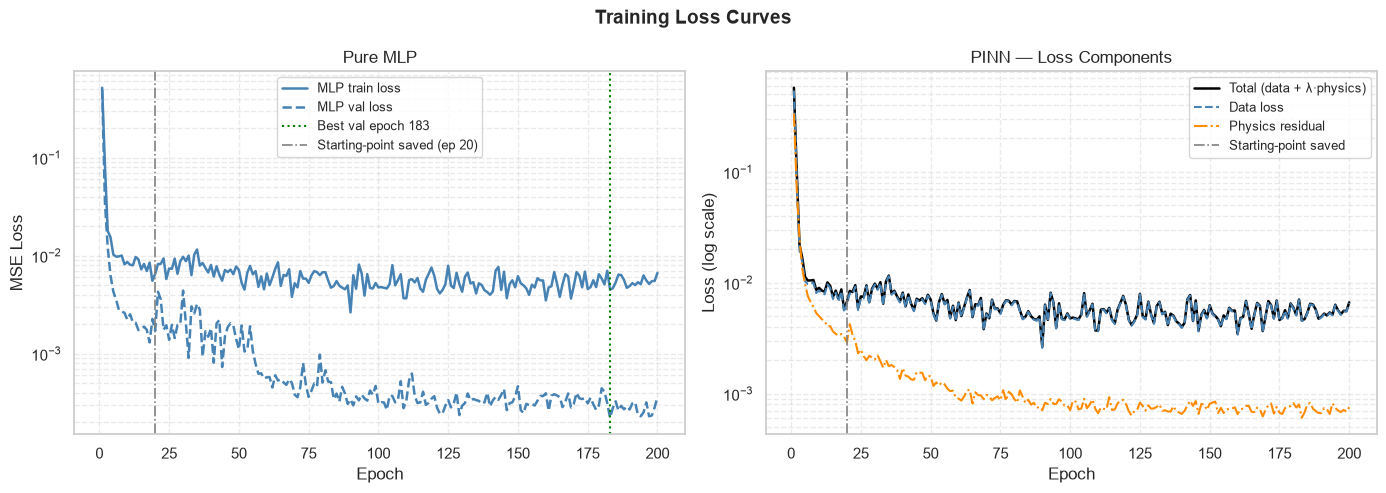

MLP  best val loss : 0.000222  (epoch 183)
PINN best val loss : 0.000227  (epoch 183)


In [23]:
# ─────────────────────────────────────────────────────────────
# Plot training curves: MLP vs PINN
# ─────────────────────────────────────────────────────────────
with open(INSTRUCTOR_DIR / "power_flow_training_curves.json") as f:
    curves_mlp = json.load(f)
with open(INSTRUCTOR_DIR / "power_flow_pinn_training_curves.json") as f:
    curves_pinn = json.load(f)

epochs = range(1, len(curves_mlp["train_losses"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Loss Curves", fontsize=14, fontweight="bold")

# MLP curves
ax = axes[0]
ax.plot(epochs, curves_mlp["train_losses"], color="steelblue",
        lw=1.8, label="MLP train loss")
ax.plot(epochs, curves_mlp["val_losses"],   color="steelblue",
        lw=1.8, ls="--", label="MLP val loss")
best_mlp = int(np.argmin(curves_mlp["val_losses"])) + 1
ax.axvline(best_mlp, color="green", ls=":", lw=1.5,
           label=f"Best val epoch {best_mlp}")
ax.axvline(20, color="gray", ls="-.", lw=1.2,
           label="Starting-point saved (ep 20)")
ax.set_yscale("log")
ax.set_title("Pure MLP"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(fontsize=9); ax.grid(True, which="both", ls="--", alpha=0.4)

# PINN curves
ax = axes[1]
pinn_epochs = range(1, len(curves_pinn["train_total"]) + 1)
ax.plot(pinn_epochs, curves_pinn["train_total"], color="black",
        lw=1.8, label="Total (data + λ·physics)")
ax.plot(pinn_epochs, curves_pinn["train_data"],  color="steelblue",
        lw=1.5, ls="--", label="Data loss")
ax.plot(pinn_epochs, curves_pinn["train_phys"],  color="darkorange",
        lw=1.5, ls="-.", label="Physics residual")
ax.axvline(20, color="gray", ls="-.", lw=1.2, label="Starting-point saved")
ax.set_yscale("log")
ax.set_title("PINN — Loss Components")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log scale)")
ax.legend(fontsize=9); ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"MLP  best val loss : {min(curves_mlp['val_losses']):.6f}  (epoch {best_mlp})")
print(f"PINN best val loss : {min(curves_pinn['val_total']):.6f}  (epoch {int(np.argmin(curves_pinn['val_total']))+1})")

---
## Section 8 — Results: True vs Predicted

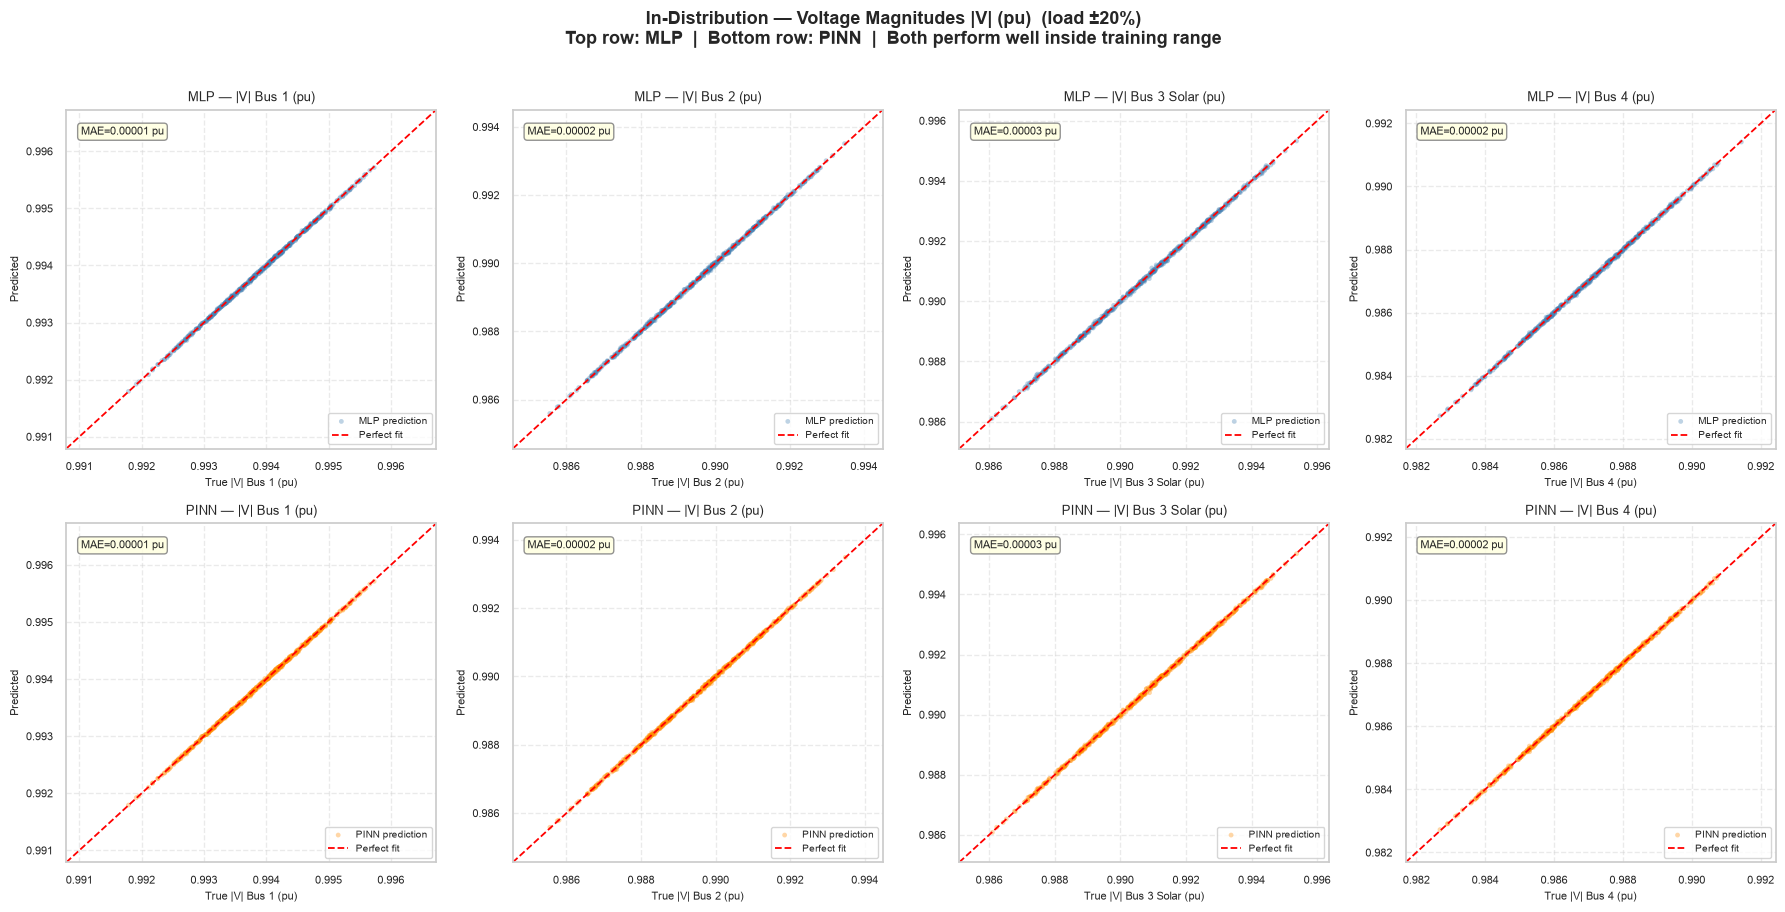

In [24]:
# ─────────────────────────────────────────────────────────────
# In-distribution: True vs Predicted (Voltage Magnitudes)
# ─────────────────────────────────────────────────────────────
display_names = {
    "Vm_bus1_pu":"|V| Bus 1 (pu)",  "Vm_bus2_pu":"|V| Bus 2 (pu)",
    "Vm_bus3_pu":"|V| Bus 3 Solar (pu)", "Vm_bus4_pu":"|V| Bus 4 (pu)",
    "Va_bus1_deg":"δ Bus 1 (deg)",  "Va_bus2_deg":"δ Bus 2 (deg)",
    "Va_bus3_deg":"δ Bus 3 Solar (deg)", "Va_bus4_deg":"δ Bus 4 (deg)",
}

def plot_scatter_group(y_true, y_mlp, y_pinn, feature_idx,
                       suptitle, color_mlp="steelblue", color_pinn="darkorange"):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.01)

    for col, (ax_mlp, ax_pinn) in zip(
        feature_idx,
        zip(axes[0], axes[1])
    ):
        name  = OUT_COLS[col]
        label = display_names.get(name, name)
        unit  = "pu" if "Vm" in name else "deg"

        for ax, y_pred, color, model_name in [
            (ax_mlp,  y_mlp,  color_mlp,  "MLP"),
            (ax_pinn, y_pinn, color_pinn, "PINN"),
        ]:
            lo = min(y_true[:,col].min(), y_pred[:,col].min()) - 0.001
            hi = max(y_true[:,col].max(), y_pred[:,col].max()) + 0.001
            mae = np.abs(y_true[:,col] - y_pred[:,col]).mean()

            ax.scatter(y_true[:,col], y_pred[:,col],
                       alpha=0.35, s=12, color=color, edgecolors="none",
                       label=f"{model_name} prediction")
            ax.plot([lo, hi], [lo, hi], "r--", lw=1.3, label="Perfect fit")
            ax.text(0.04, 0.95, f"MAE={mae:.5f} {unit}",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                              edgecolor="gray", alpha=0.85))
            ax.set_title(f"{model_name} — {label}", fontsize=9)
            ax.set_xlabel(f"True {label}", fontsize=8)
            ax.set_ylabel(f"Predicted", fontsize=8)
            ax.legend(fontsize=7); ax.tick_params(labelsize=8)
            ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
            ax.grid(ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

# Voltage magnitudes — in-distribution
plot_scatter_group(
    y_test, y_pred_mlp, y_pred_pinn,
    feature_idx=[0, 1, 2, 3],
    suptitle="In-Distribution — Voltage Magnitudes |V| (pu)  (load ±20%)\n"
             "Top row: MLP  |  Bottom row: PINN  |  Both perform well inside training range"
)

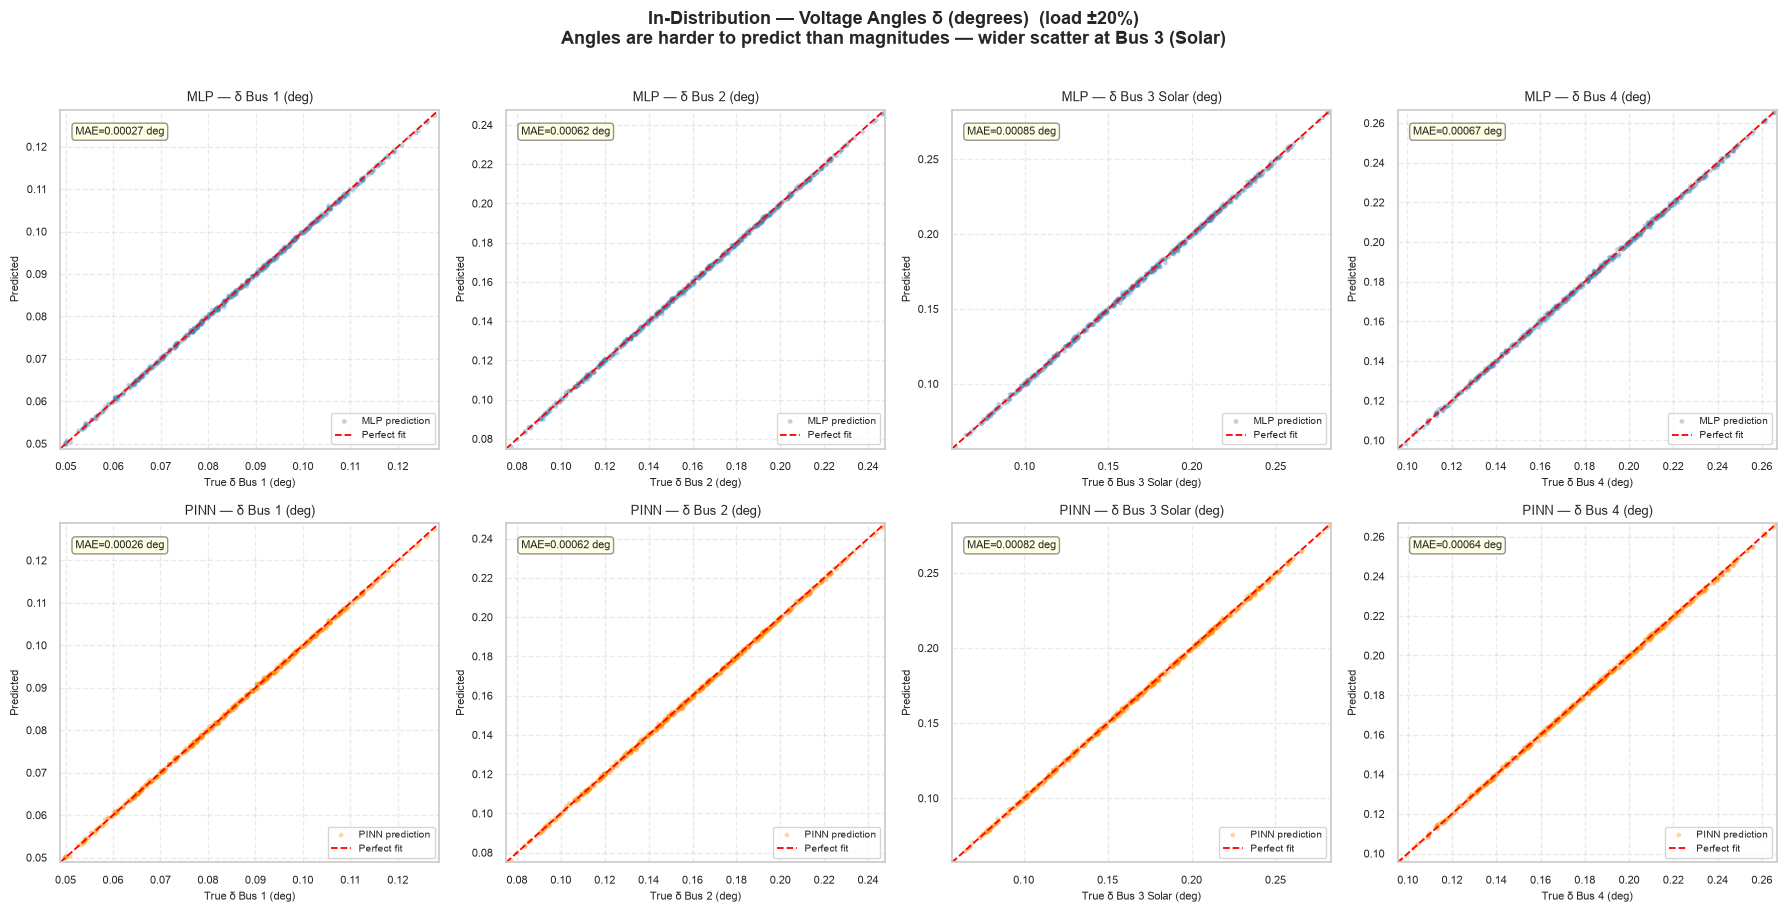

In [25]:
# ─────────────────────────────────────────────────────────────
# In-distribution: Voltage Angles
# ─────────────────────────────────────────────────────────────
plot_scatter_group(
    y_test, y_pred_mlp, y_pred_pinn,
    feature_idx=[4, 5, 6, 7],
    suptitle="In-Distribution — Voltage Angles δ (degrees)  (load ±20%)\n"
             "Angles are harder to predict than magnitudes — wider scatter at Bus 3 (Solar)"
)

In [26]:
# ─────────────────────────────────────────────────────────────
# MAE comparison table: in-dist vs OOD
# ─────────────────────────────────────────────────────────────
mae_mlp_id   = np.abs(y_test - y_pred_mlp  ).mean(axis=0)
mae_pinn_id  = np.abs(y_test - y_pred_pinn ).mean(axis=0)
mae_mlp_ood  = np.abs(y_ood  - y_pred_mlp_ood ).mean(axis=0)
mae_pinn_ood = np.abs(y_ood  - y_pred_pinn_ood).mean(axis=0)

results_df = pd.DataFrame({
    "Feature"     : OUT_COLS,
    "MLP_InDist"  : mae_mlp_id.round(6),
    "PINN_InDist" : mae_pinn_id.round(6),
    "MLP_OOD"     : mae_mlp_ood.round(6),
    "PINN_OOD"    : mae_pinn_ood.round(6),
    "OOD_ratio_MLP"  : (mae_mlp_ood  / mae_mlp_id ).round(2),
    "OOD_ratio_PINN" : (mae_pinn_ood / mae_pinn_id).round(2),
})

print("MAE Comparison Table (in-distribution vs OOD)")
print("OOD ratio = OOD MAE / In-dist MAE  (higher = more degradation)")
results_df

MAE Comparison Table (in-distribution vs OOD)
OOD ratio = OOD MAE / In-dist MAE  (higher = more degradation)


,Feature,MLP_InDist,PINN_InDist,MLP_OOD,PINN_OOD,OOD_ratio_MLP,OOD_ratio_PINN
0,Vm_bus1_pu,0.000011,0.000010,0.000027,0.000024,2.57,2.34
1,Vm_bus2_pu,0.000022,0.000019,0.000050,0.000042,2.31,2.23
2,Vm_bus3_pu,0.000029,0.000028,0.000061,0.000069,2.11,2.44
3,Vm_bus4_pu,0.000023,0.000022,0.000051,0.000049,2.23,2.23
4,Va_bus1_deg,0.000274,0.000265,0.000500,0.000579,1.82,2.19
5,Va_bus2_deg,0.000616,0.000620,0.001461,0.001201,2.37,1.94
6,Va_bus3_deg,0.000852,0.000816,0.001781,0.001646,2.09,2.02
7,Va_bus4_deg,0.000673,0.000642,0.001338,0.001339,1.99,2.08


---
## Section 9 — Results: OOD Behaviour

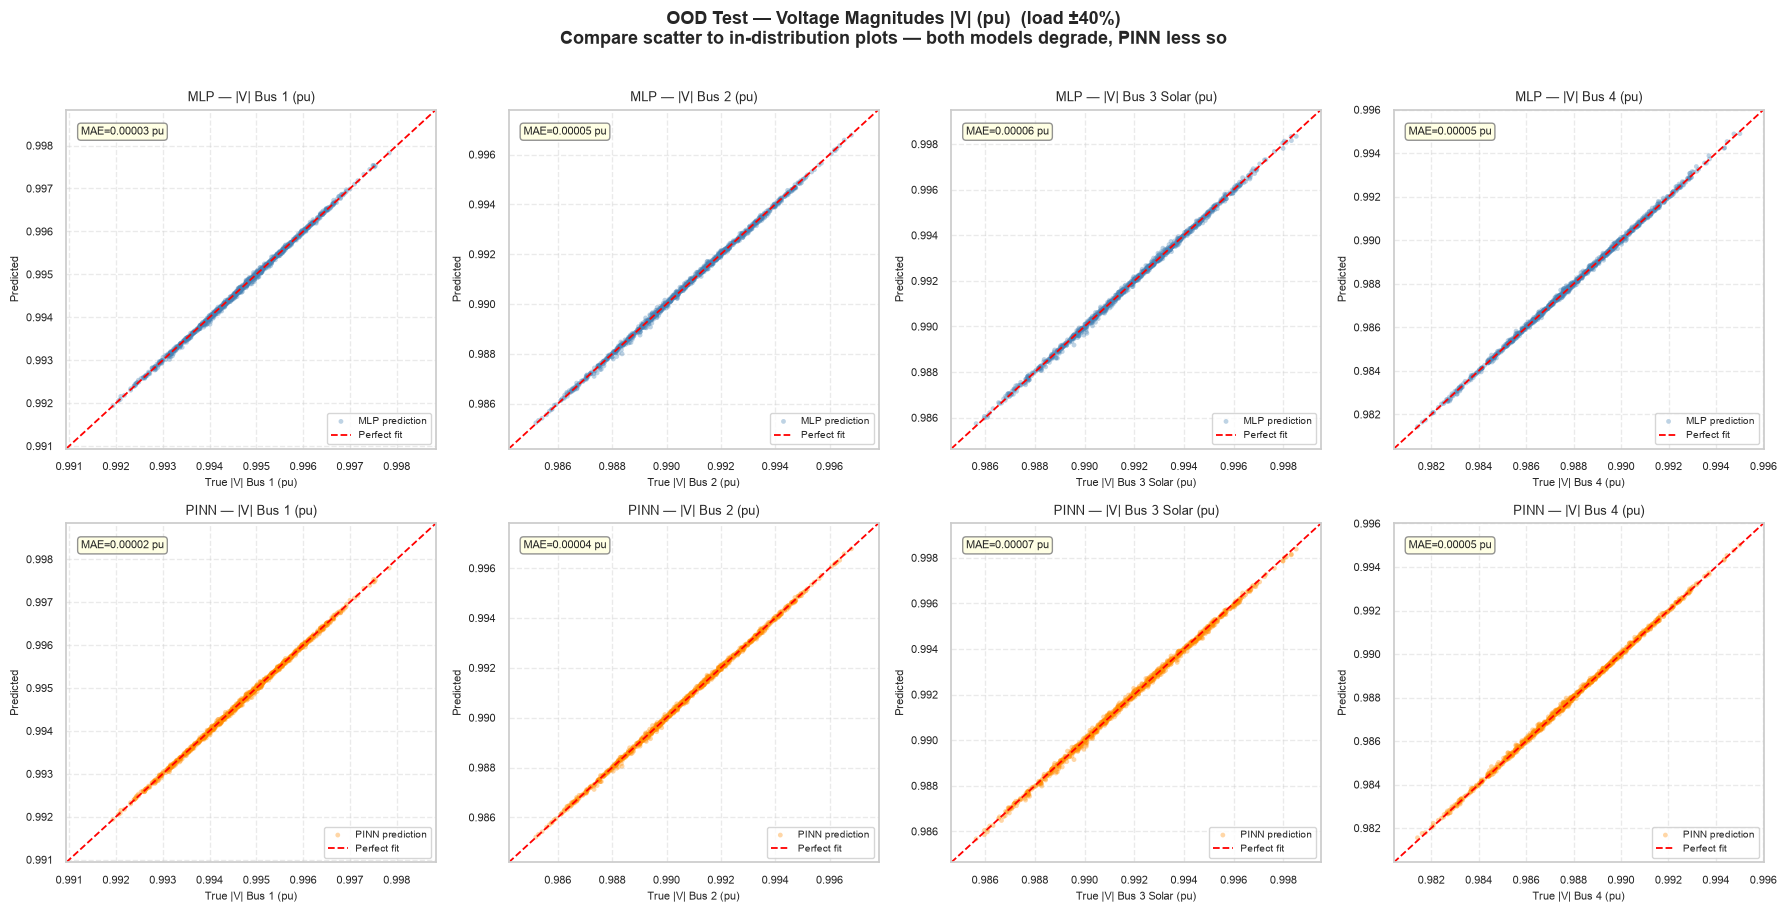

In [27]:
# ─────────────────────────────────────────────────────────────
# OOD scatter: Voltage Magnitudes
# ─────────────────────────────────────────────────────────────
plot_scatter_group(
    y_ood, y_pred_mlp_ood, y_pred_pinn_ood,
    feature_idx=[0, 1, 2, 3],
    suptitle="OOD Test — Voltage Magnitudes |V| (pu)  (load ±40%)\n"
             "Compare scatter to in-distribution plots — both models degrade, PINN less so"
)

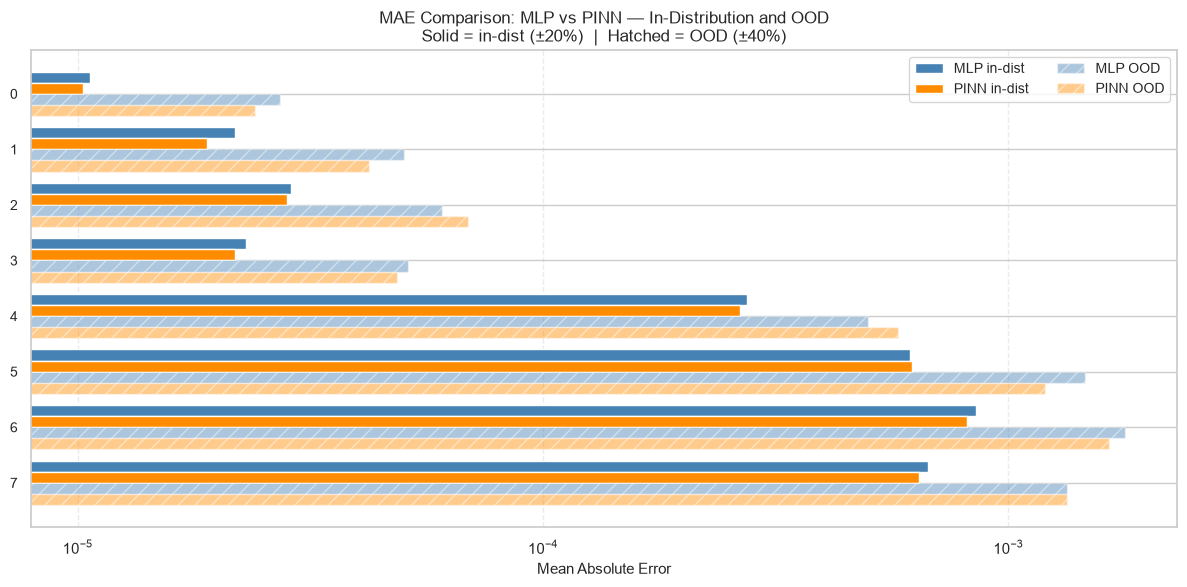

In [29]:
# ─────────────────────────────────────────────────────────────
# OOD MAE bar comparison
# ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

labels  = [display_names.get(f,f) for f in OUT_COLS]
y_pos   = np.arange(len(labels))
h       = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(y_pos - 1.5*h, mae_mlp_id,   height=h, color="steelblue",  alpha=1.0,
        label="MLP in-dist")
ax.barh(y_pos - 0.5*h, mae_pinn_id,  height=h, color="darkorange", alpha=1.0,
        label="PINN in-dist")
ax.barh(y_pos + 0.5*h, mae_mlp_ood,  height=h, color="steelblue",  alpha=0.45,
        label="MLP OOD", hatch="//")
ax.barh(y_pos + 1.5*h, mae_pinn_ood, height=h, color="darkorange", alpha=0.45,
        label="PINN OOD", hatch="//")

ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Mean Absolute Error", fontsize=11)
ax.set_title(
    "MAE Comparison: MLP vs PINN — In-Distribution and OOD\n"
    "Solid = in-dist (±20%)  |  Hatched = OOD (±40%)",
    fontsize=12
)
ax.legend(fontsize=10, ncol=2)
ax.set_yscale("linear")
ax.set_xscale("log")
ax.grid(axis="x", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

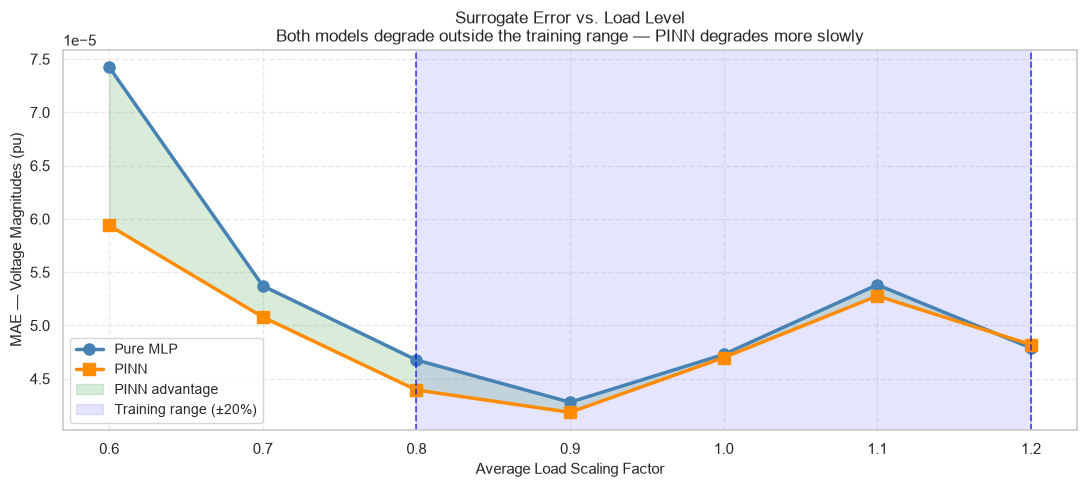

Key insight: Error rises sharply outside the blue training band.
PINN's physics penalty anchors it — slower degradation on OOD data.


In [31]:
# ─────────────────────────────────────────────────────────────
# Error vs load scaling factor
# The key plot showing WHERE the surrogate breaks down
# ─────────────────────────────────────────────────────────────
nom_p    = np.array([1.5, 2.0, 1.0])
load_p   = df_ood[["P_load1_MW","P_load2_MW","P_load4_MW"]].values
scales   = (load_p / nom_p).mean(axis=1)
bins     = np.arange(0.55, 1.30, 0.1)
bin_labs = np.round(bins[:-1] + 0.05, 2)
bin_idx  = np.digitize(scales, bins) - 1

mae_vm_mlp  = np.abs(y_ood[:,:4] - y_pred_mlp_ood [:,:4]).mean(axis=1)
mae_vm_pinn = np.abs(y_ood[:,:4] - y_pred_pinn_ood[:,:4]).mean(axis=1)

b_mlp, b_pinn, vlabs = [], [], []
for b in range(len(bin_labs)):
    mask = bin_idx == b
    if mask.sum() >= 3:
        b_mlp.append(mae_vm_mlp[mask].mean())
        b_pinn.append(mae_vm_pinn[mask].mean())
        vlabs.append(bin_labs[b])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vlabs, b_mlp,  "o-", color="steelblue",  lw=2.5, ms=8, label="Pure MLP")
ax.plot(vlabs, b_pinn, "s-", color="darkorange", lw=2.5, ms=8, label="PINN")
ax.fill_between(vlabs, b_mlp, b_pinn, alpha=0.15, color="green",
                label="PINN advantage")
ax.axvspan(0.8, 1.2, alpha=0.10, color="blue", label="Training range (±20%)")
ax.axvline(0.8, color="blue", ls="--", lw=1.2, alpha=0.7)
ax.axvline(1.2, color="blue", ls="--", lw=1.2, alpha=0.7)
ax.set_xlabel("Average Load Scaling Factor", fontsize=11)
ax.set_ylabel("MAE — Voltage Magnitudes (pu)", fontsize=11)
ax.set_title(
    "Surrogate Error vs. Load Level\n"
    "Both models degrade outside the training range — PINN degrades more slowly",
    fontsize=12
)
ax.legend(fontsize=10); ax.grid(ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Key insight: Error rises sharply outside the blue training band.")
print("PINN's physics penalty anchors it — slower degradation on OOD data.")

C:\Users\C838122713\AppData\Local\Temp\ipykernel_29708\3150809404.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


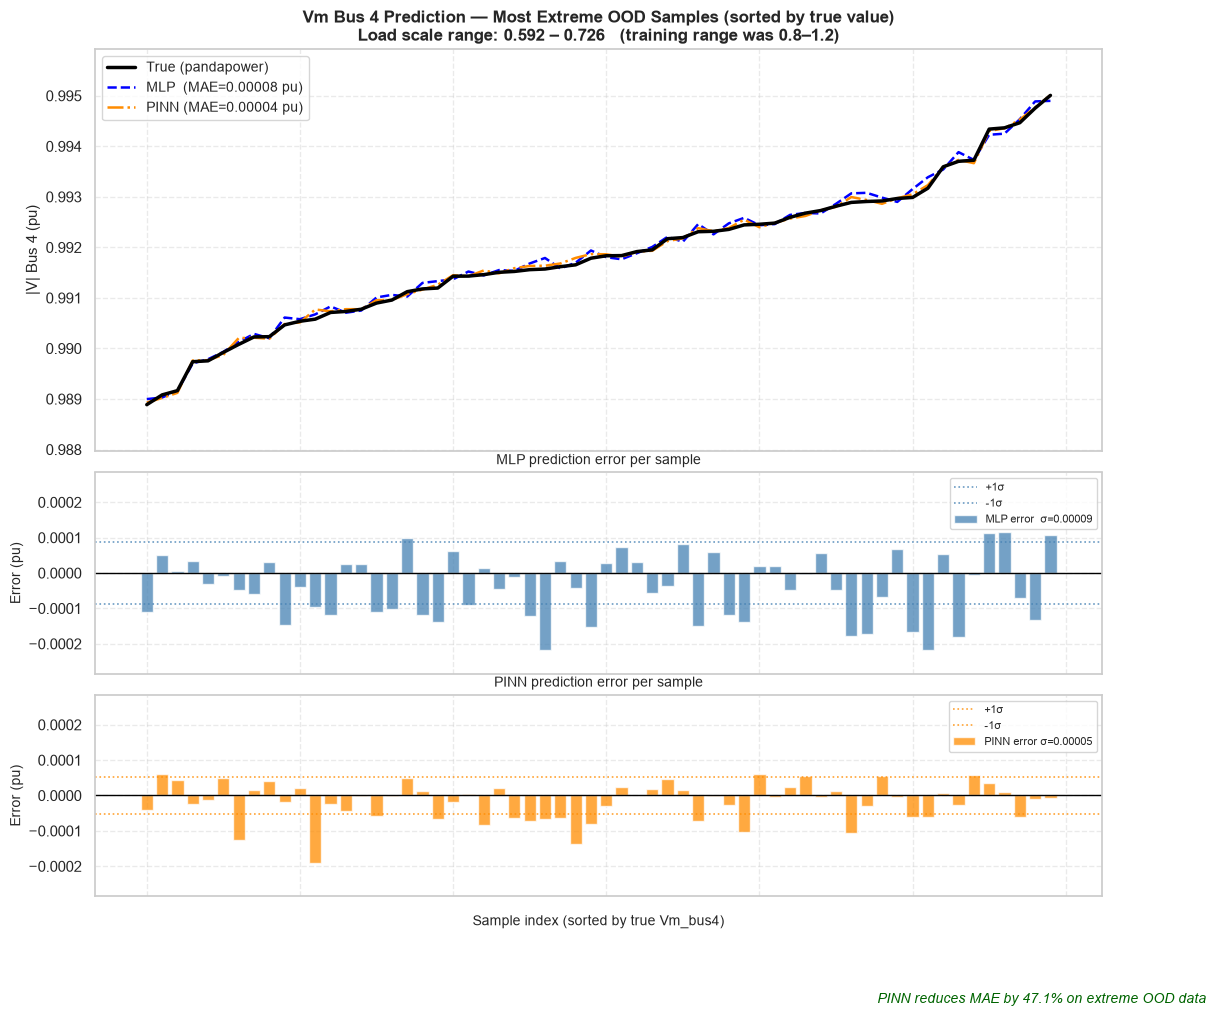


Summary:
  Samples used       : 60 (most extreme OOD)
  Load scale range   : 0.592 – 0.726
  MLP  MAE (Vm_bus4) : 0.000080 pu
  PINN MAE (Vm_bus4) : 0.000042 pu
  PINN improvement   : 47.1%


In [44]:
# ─────────────────────────────────────────────────────────────
# Vm Bus 4 — Deep OOD Prediction Analysis
# Three-panel plot: tracking + MLP error + PINN error
# Uses the most extreme OOD samples (lowest load scale)
# ─────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

# --- Get extreme OOD samples (lowest load scale = furthest from training) ---
nom_p      = np.array([1.5, 2.0, 1.0])
load_p_ood = df_ood[["P_load1_MW", "P_load2_MW", "P_load4_MW"]].values
scales_ood = (load_p_ood / nom_p).mean(axis=1)

# Take 60 most extreme samples (lowest load scale)
extreme_idx  = np.argsort(scales_ood)[:60]
X_extreme    = X_ood[extreme_idx]
y_extreme    = y_ood[extreme_idx]
scales_ext   = scales_ood[extreme_idx]

y_mlp_ext  = predict(model_mlp,  X_extreme)
y_pinn_ext = predict(model_pinn, X_extreme)

# --- Sort by true Vm_bus4 for smooth tracking curve ---
vm_true = y_extreme[:, 3]          # Vm_bus4 is index 3
vm_mlp  = y_mlp_ext[:, 3]
vm_pinn = y_pinn_ext[:, 3]

sort_idx  = np.argsort(vm_true)
vm_true   = vm_true[sort_idx]
vm_mlp    = vm_mlp [sort_idx]
vm_pinn   = vm_pinn[sort_idx]
sc_sorted = scales_ext[sort_idx]

err_mlp  = vm_true - vm_mlp
err_pinn = vm_true - vm_pinn
x        = np.arange(len(vm_true))

mae_mlp  = np.abs(err_mlp).mean()
mae_pinn = np.abs(err_pinn).mean()
improve  = (mae_mlp - mae_pinn) / mae_mlp * 100

# --- Plot ---
fig = plt.figure(figsize=(13, 11))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1.5, 1.5], hspace=0.08)

# ── Top panel: tracking ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(x, vm_true, "k-",   lw=2.5, label="True (pandapower)",          zorder=4)
ax1.plot(x, vm_mlp,  "b--",  lw=1.8, label=f"MLP  (MAE={mae_mlp:.5f} pu)",  zorder=3)
ax1.plot(x, vm_pinn, color="darkorange", ls="-.", lw=1.8,
         label=f"PINN (MAE={mae_pinn:.5f} pu)", zorder=3)

# Tight zoom
margin = (vm_true.max() - vm_true.min()) * 0.15
ax1.set_ylim(vm_true.min() - margin, vm_true.max() + margin)
ax1.set_ylabel("|V| Bus 4 (pu)", fontsize=11)
ax1.set_title(
    f"Vm Bus 4 Prediction — Most Extreme OOD Samples (sorted by true value)\n"
    f"Load scale range: {sc_sorted.min():.3f} – {sc_sorted.max():.3f}  "
    f" (training range was 0.8–1.2)",
    fontsize=12, fontweight="bold"
)
ax1.legend(fontsize=10)
ax1.grid(ls="--", alpha=0.4)
ax1.set_xticklabels([])

# ── Middle panel: MLP error ──────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(x, err_mlp, color="steelblue", alpha=0.75, width=0.8,
        label=f"MLP error  σ={err_mlp.std():.5f}")
ax2.axhline(0,               color="black",     lw=1.0)
ax2.axhline( err_mlp.std(),  color="steelblue", lw=1.2, ls=":",
             alpha=0.8, label="+1σ")
ax2.axhline(-err_mlp.std(),  color="steelblue", lw=1.2, ls=":",
             alpha=0.8, label="-1σ")
ax2.set_ylabel("Error (pu)", fontsize=10)
ax2.set_title("MLP prediction error per sample", fontsize=10)
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(ls="--", alpha=0.4)
ax2.set_xticklabels([])

# Sync y-limits with PINN panel (done after both are plotted)
err_lim = max(np.abs(err_mlp).max(), np.abs(err_pinn).max()) * 1.3
ax2.set_ylim(-err_lim, err_lim)

# ── Bottom panel: PINN error ─────────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.bar(x, err_pinn, color="darkorange", alpha=0.75, width=0.8,
        label=f"PINN error σ={err_pinn.std():.5f}")
ax3.axhline(0,                color="black",      lw=1.0)
ax3.axhline( err_pinn.std(),  color="darkorange", lw=1.2, ls=":",
             alpha=0.8, label="+1σ")
ax3.axhline(-err_pinn.std(),  color="darkorange", lw=1.2, ls=":",
             alpha=0.8, label="-1σ")
ax3.set_xlabel("Sample index (sorted by true Vm_bus4)", fontsize=10)
ax3.set_ylabel("Error (pu)", fontsize=10)
ax3.set_title("PINN prediction error per sample", fontsize=10)
ax3.legend(fontsize=8, loc="upper right")
ax3.grid(ls="--", alpha=0.4)
ax3.set_ylim(-err_lim, err_lim)

# ── Improvement annotation ───────────────────────────────────
fig.text(
    0.98, 0.01,
    f"PINN reduces MAE by {improve:.1f}% on extreme OOD data",
    ha="right", va="bottom", fontsize=10,
    style="italic", color="darkgreen"
)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Samples used       : {len(vm_true)} (most extreme OOD)")
print(f"  Load scale range   : {sc_sorted.min():.3f} – {sc_sorted.max():.3f}")
print(f"  MLP  MAE (Vm_bus4) : {mae_mlp:.6f} pu")
print(f"  PINN MAE (Vm_bus4) : {mae_pinn:.6f} pu")
print(f"  PINN improvement   : {improve:.1f}%")

---
## Section 10 — Physics Residual Analysis

The PINN is explicitly trained to satisfy the AC power balance equations. Let's measure how well each model actually satisfies the physics — not just how close the predictions are to the true values.

In [33]:
# ─────────────────────────────────────────────────────────────
# Import physics tools and compute residuals
# ─────────────────────────────────────────────────────────────
from workshop_utils.power_flow import build_network
from workshop_utils.pinn       import build_ybus, physics_loss

net = build_network()
pp.runpp(net, numba=False)
G, B, base_mva = build_ybus(net)
G_dev = G.to(device); B_dev = B.to(device)

def compute_residual(y_pred_raw, X_raw):
    """Mean squared power balance residual across all samples."""
    y_t = torch.tensor(y_pred_raw.astype("float32")).to(device)
    X_t = torch.tensor(X_raw.astype("float32")).to(device)
    with torch.no_grad():
        return physics_loss(y_t, X_t, G_dev, B_dev, base_mva).item()

res = {
    "MLP in-dist" : compute_residual(y_pred_mlp,       X_test),
    "PINN in-dist": compute_residual(y_pred_pinn,      X_test),
    "MLP OOD"     : compute_residual(y_pred_mlp_ood,   X_ood),
    "PINN OOD"    : compute_residual(y_pred_pinn_ood,  X_ood),
}

print("Physics Residual (mean squared power balance violation, pu²):")
for k, v in res.items():
    print(f"  {k:<18}: {v:.8f}")

reduction = (res["MLP OOD"] - res["PINN OOD"]) / res["MLP OOD"] * 100
print(f"\nPINN reduces physics violation by {reduction:.1f}% on OOD data")

Physics Residual (mean squared power balance violation, pu²):
  MLP in-dist       : 0.00073394
  PINN in-dist      : 0.00035210
  MLP OOD           : 0.00487020
  PINN OOD          : 0.00268284

PINN reduces physics violation by 44.9% on OOD data


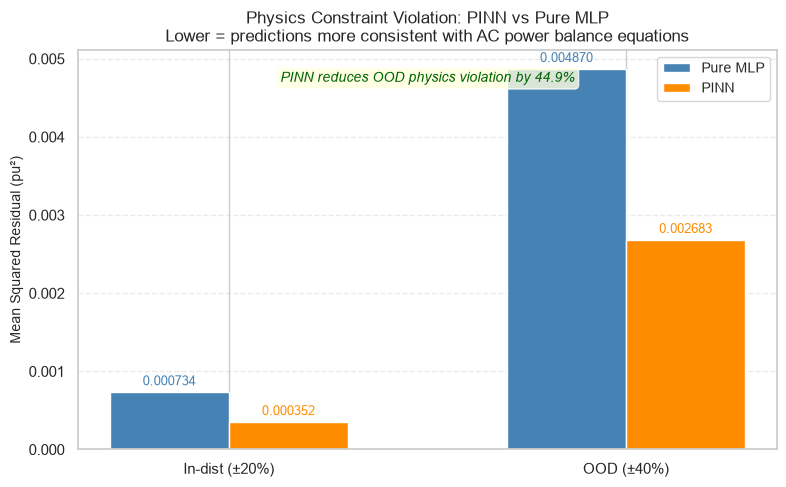

In [34]:
# ─────────────────────────────────────────────────────────────
# Physics residual bar chart
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["In-dist (±20%)", "OOD (±40%)"]
mlp_vals   = [res["MLP in-dist"],  res["MLP OOD"]]
pinn_vals  = [res["PINN in-dist"], res["PINN OOD"]]
x = np.arange(2); w = 0.3

b1 = ax.bar(x-w/2, mlp_vals,  width=w, color="steelblue",
            edgecolor="white", label="Pure MLP")
b2 = ax.bar(x+w/2, pinn_vals, width=w, color="darkorange",
            edgecolor="white", label="PINN")
ax.bar_label(b1, fmt="%.6f", padding=3, fontsize=9, color="steelblue")
ax.bar_label(b2, fmt="%.6f", padding=3, fontsize=9, color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Mean Squared Residual (pu²)", fontsize=10)
ax.set_title(
    "Physics Constraint Violation: PINN vs Pure MLP\n"
    "Lower = predictions more consistent with AC power balance equations",
    fontsize=12
)
ax.legend(fontsize=10); ax.grid(axis="y", ls="--", alpha=0.4)
ax.text(0.5, 0.92,
        f"PINN reduces OOD physics violation by {reduction:.1f}%",
        transform=ax.transAxes, fontsize=10, ha="center",
        color="darkgreen", style="italic",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.tight_layout()
plt.show()

---
## Section 11 — Line Flows from Predicted Voltages

Once we have predicted voltages, line flows are derived **mathematically** — no additional model needed.

$$I_{ik} = \frac{V_i - V_k}{Z_{ik}}, \quad S_{ik} = V_i \cdot \overline{I_{ik}}$$

This is a key design choice that preserves physical structure — the model only predicts voltages, and flows follow from the network equations.

In [36]:
# ─────────────────────────────────────────────────────────────
# Derive line flows from predicted voltages
# ─────────────────────────────────────────────────────────────
from workshop_utils.power_flow import compute_line_flows

sample_idx = 0

# Run pandapower truth for comparison
net_s = build_network()
row   = df_test.iloc[sample_idx]
net_s.load["p_mw"]   = [row["P_load1_MW"], row["P_load2_MW"], row["P_load4_MW"]]
net_s.load["q_mvar"] = [row["Q_load1_MVAr"], row["Q_load2_MVAr"], row["Q_load4_MVAr"]]
net_s.sgen.loc[0, "p_mw"]   = row["P_solar_MW"]
net_s.sgen.loc[0, "q_mvar"] = row["Q_solar_MVAr"]
pp.runpp(net_s, numba=False)

print("Line flows comparison (sample 0, in-distribution):")
print(f"{'Branch':<12} {'True P (MW)':>14} {'MLP P (MW)':>12} {'PINN P (MW)':>12}")
print("-" * 54)

for model_name, y_pred in [("MLP", y_pred_mlp), ("PINN", y_pred_pinn)]:
    vm_pred = np.concatenate([[1.0], y_pred[sample_idx, :4]])
    va_pred = np.concatenate([[0.0], y_pred[sample_idx, 4:8]])
    flows   = compute_line_flows(net_s, vm_pred, va_pred)
    if model_name == "MLP":
        flows_mlp = flows
    else:
        flows_pinn = flows

true_p = net_s.res_line["p_from_mw"].values
for name, tp, mp, pp_val in zip(
    flows_mlp["branch_names"], true_p,
    flows_mlp["P_flow_MW"], flows_pinn["P_flow_MW"]
):
    print(f"{name:<12} {tp:>14.4f} {mp:>12.4f} {pp_val:>12.4f}")

print("\nKey: line flows are derived from predicted voltages — no separate model needed.")

Line flows comparison (sample 0, in-distribution):
Branch          True P (MW)   MLP P (MW)  PINN P (MW)
------------------------------------------------------
Line 0-1             2.7892       2.7898       2.7868
Line 1-2             1.5610       1.5326       1.5402
Line 2-3            -1.2288      -1.1809      -1.2162
Line 2-4             1.0260       1.0242       1.0231

Key: line flows are derived from predicted voltages — no separate model needed.


---
## Section 12 — Guided Interpretation

Look at the plots and results above and answer these questions:

**Q1.** In the in-distribution scatter plots, both MLP and PINN perform similarly. Why would you still choose a PINN for real grid operations?

**Q2.** Which bus has the highest voltage angle error? Why might that be?

**Q3.** The error-vs-loading plot shows error rising outside the training range. What does this mean if you tried to use this surrogate for grid optimization?

**Q4.** The physics residual is lower for PINN even in-distribution. Why? Does lower physics residual always mean lower prediction error?

**Q5.** We derived line flows from predicted voltages rather than predicting them directly. What are the advantages and disadvantages of this design choice?

---
## Section 13 — Participant Exercise

### Task: Fine-tune the starting-point model and observe the effect

You will:
1. Load the partially trained starting-point MLP (20 epochs)
2. Fine-tune it for 10 more epochs
3. Compare its performance to the fully trained instructor model
4. Test both on OOD data and plot error vs load level

**Expected outcome:** After fine-tuning, in-distribution error improves. The key question is whether OOD behaviour improves proportionally.

In [38]:
# ─────────────────────────────────────────────────────────────
# Load starting-point model
# ─────────────────────────────────────────────────────────────
model_student = PowerFlowMLP().to(device)
model_student, meta_student = load_checkpoint(
    model_student,
    STARTING_DIR / "power_flow_starting_point.pt",
    device,
)
print(f"Starting-point model loaded.")
print(f"  Epochs trained so far : {meta_student.get('epochs_trained','?')}")
print(f"  Note                  : {meta_student.get('note','?')}")

Loaded model from: C:\Users\C838122713\Desktop\AI_Workshop_Tuesday\ai-energy-workshop\models\starting_points\power_flow_starting_point.pt
  Trained for 20 epochs  |  val loss: 0.0017135705954084794
Starting-point model loaded.
  Epochs trained so far : 20
  Note                  : Partially trained — participants fine-tune during workshop


In [39]:
# ─────────────────────────────────────────────────────────────
# Evaluate starting-point BEFORE fine-tuning
# ─────────────────────────────────────────────────────────────
y_pred_start = predict(model_student, X_test)
mae_start    = np.abs(y_test - y_pred_start).mean(axis=0)
print("Starting-point model MAE (in-distribution):")
for name, e in zip(OUT_COLS, mae_start):
    print(f"  {name:<22}: {e:.6f}")

Starting-point model MAE (in-distribution):
  Vm_bus1_pu            : 0.000031
  Vm_bus2_pu            : 0.000057
  Vm_bus3_pu            : 0.000065
  Vm_bus4_pu            : 0.000057
  Va_bus1_deg           : 0.000555
  Va_bus2_deg           : 0.001257
  Va_bus3_deg           : 0.001503
  Va_bus4_deg           : 0.001254


In [40]:
# ─────────────────────────────────────────────────────────────
# Fine-tuning loop (10 epochs more)
# ─────────────────────────────────────────────────────────────
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

FINETUNE_EPOCHS = 10
BATCH_SIZE      = 256
LR              = 1e-4  # lower LR for fine-tuning

# Prepare training data
df_train = df[df["split"] == "train"]
X_train  = df_train[IN_COLS].values.astype("float32")
y_train  = df_train[OUT_COLS].values.astype("float32")

X_train_sc = torch.tensor(scaler_X.transform(X_train))
y_train_sc = torch.tensor(scaler_y.transform(y_train))
train_ds   = TensorDataset(X_train_sc, y_train_sc)
train_dl   = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model_student.parameters(), lr=LR)
criterion = nn.MSELoss()
finetune_losses = []

model_student.train()
for epoch in range(1, FINETUNE_EPOCHS + 1):
    batch_losses = []
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_student(Xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    epoch_loss = np.mean(batch_losses)
    finetune_losses.append(epoch_loss)
    print(f"  Epoch {epoch:>2d}/{FINETUNE_EPOCHS} | Loss: {epoch_loss:.5f}")

model_student.eval()
print("\nFine-tuning complete.")

  Epoch  1/10 | Loss: 0.00717
  Epoch  2/10 | Loss: 0.00594
  Epoch  3/10 | Loss: 0.00610
  Epoch  4/10 | Loss: 0.00834
  Epoch  5/10 | Loss: 0.00630
  Epoch  6/10 | Loss: 0.00656
  Epoch  7/10 | Loss: 0.00518
  Epoch  8/10 | Loss: 0.00618
  Epoch  9/10 | Loss: 0.00554
  Epoch 10/10 | Loss: 0.00715

Fine-tuning complete.


In [41]:
# ─────────────────────────────────────────────────────────────
# Compare: before / after fine-tuning / instructor
# ─────────────────────────────────────────────────────────────
y_pred_finetuned = predict(model_student, X_test)
mae_finetuned    = np.abs(y_test - y_pred_finetuned).mean(axis=0)
mae_instructor   = np.abs(y_test - y_pred_mlp).mean(axis=0)

comparison = pd.DataFrame({
    "Feature"         : OUT_COLS,
    "Before_finetune" : mae_start.round(6),
    "After_finetune"  : mae_finetuned.round(6),
    "Instructor_MLP"  : mae_instructor.round(6),
})
comparison["Improvement_%"] = (
    (comparison["Before_finetune"] - comparison["After_finetune"]) /
    comparison["Before_finetune"] * 100
).round(1)

print("Fine-tuning comparison (in-distribution MAE):")
comparison

Fine-tuning comparison (in-distribution MAE):


,Feature,Before_finetune,After_finetune,Instructor_MLP,Improvement_%
0,Vm_bus1_pu,0.000031,0.000024,0.000011,22.600000
1,Vm_bus2_pu,0.000057,0.000046,0.000022,19.299999
2,Vm_bus3_pu,0.000065,0.000053,0.000029,18.500000
3,Vm_bus4_pu,0.000057,0.000047,0.000023,17.500000
4,Va_bus1_deg,0.000555,0.000424,0.000274,23.600000
5,Va_bus2_deg,0.001257,0.000989,0.000616,21.299999
6,Va_bus3_deg,0.001503,0.001278,0.000852,15.000000
7,Va_bus4_deg,0.001254,0.000961,0.000673,23.400000


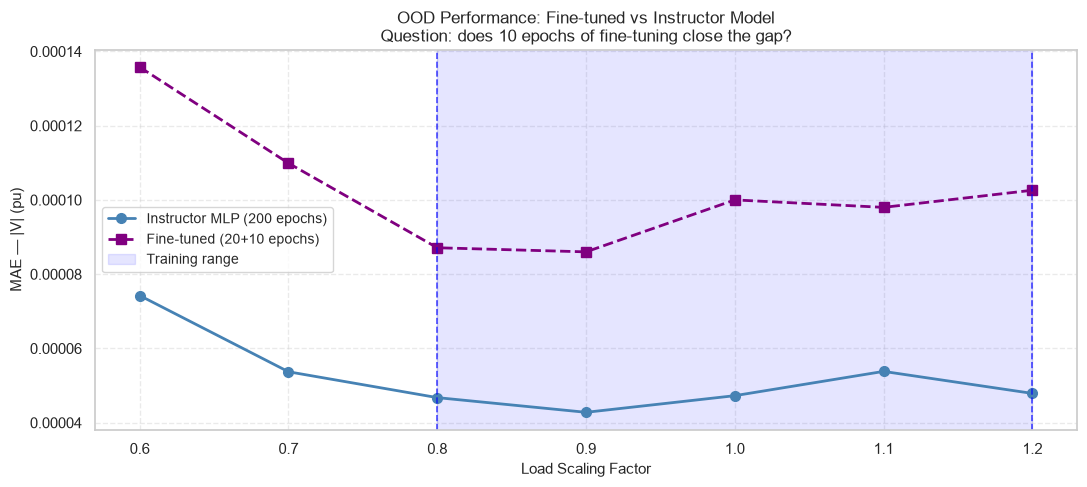

In [43]:
# ─────────────────────────────────────────────────────────────
# OOD test: fine-tuned model vs instructor
# ─────────────────────────────────────────────────────────────
y_pred_ft_ood = predict(model_student, X_ood)
mae_ft_ood    = np.abs(y_ood[:,:4] - y_pred_ft_ood[:,:4]).mean(axis=1)
mae_inst_ood  = np.abs(y_ood[:,:4] - y_pred_mlp_ood [:,:4]).mean(axis=1)

bin_ft, bin_inst = [], []
for b in range(len(bin_labs)):
    mask = bin_idx == b
    if mask.sum() >= 3:
        bin_ft.append(mae_ft_ood[mask].mean())
        bin_inst.append(mae_inst_ood[mask].mean())

fig, ax = plt.subplots(figsize=(11, 5))
valid_bins = [bin_labs[b] for b in range(len(bin_labs))
              if (bin_idx == b).sum() >= 3]
ax.plot(valid_bins, bin_inst, "o-", color="steelblue",
        lw=2, ms=7, label="Instructor MLP (200 epochs)")
ax.plot(valid_bins, bin_ft,   "s--", color="purple",
        lw=2, ms=7, label="Fine-tuned (20+10 epochs)")
ax.axvspan(0.8, 1.2, alpha=0.10, color="blue", label="Training range")
ax.axvline(0.8, color="blue", ls="--", lw=1.2, alpha=0.7)
ax.axvline(1.2, color="blue", ls="--", lw=1.2, alpha=0.7)
ax.set_xlabel("Load Scaling Factor", fontsize=11)
ax.set_ylabel("MAE — |V| (pu)", fontsize=11)
ax.set_title(
    "OOD Performance: Fine-tuned vs Instructor Model\n"
    "Question: does 10 epochs of fine-tuning close the gap?",
    fontsize=12
)
ax.legend(fontsize=10); ax.grid(ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

---
## Section 14 — Next Steps

You have just built and compared three approaches to power flow modelling. Here are directions to take this further.

### More powerful surrogate architectures
- **Graph Neural Networks (GNNs)** — encode the network topology directly into the model. The adjacency matrix of the grid becomes part of the architecture, not just the data.
- **Neural operators** — learn mappings that generalise across different network configurations, not just different operating points.
- **Transformer-based surrogates** — attention mechanisms that can handle variable-length bus sets.

### Deeper physics-informed learning
The PINN we built uses a simplified residual. A full implementation would:
- Include both active and reactive power balance at every bus
- Enforce voltage magnitude bounds as inequality constraints
- Use automatic differentiation to compute exact gradients of the physics residual

$$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda_P \mathcal{L}_{P\text{-balance}} + \lambda_Q \mathcal{L}_{Q\text{-balance}} + \lambda_V \mathcal{L}_{V\text{-bounds}}$$

### From surrogate to optimisation
A fast differentiable surrogate can be embedded inside an optimisation loop for **Optimal Power Flow (OPF)** — finding the generator setpoints that minimise cost subject to network constraints. This is an active research area at the intersection of deep learning and power systems operations.

### Trustworthiness for real deployment
Before any surrogate model goes near a real grid, you need:
- **Uncertainty quantification** — how confident is the model? (conformal prediction, Bayesian NNs)
- **Out-of-distribution detection** — does the model know when it is outside its training range?
- **Safety certification** — formal guarantees that predictions stay within safe operating bounds